In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -oq "/content/drive/MyDrive/WorkerSafety25_clean_5cls_70-20-10.zip" -d "/content"

In [3]:
from pathlib import Path

DATA_ROOT = Path("/content/WorkerSafety25_clean_5cls")

for split in ["train", "valid", "test"]:
    images_dir = DATA_ROOT / split / "images"
    labels_dir = DATA_ROOT / split / "labels"

    image_count = len(list(images_dir.glob("*")))
    label_count = len(list(labels_dir.glob("*.txt")))

    print(f"{split}: {image_count} images | {label_count} label files")

print("\ndata.yaml exists:", (DATA_ROOT / "data.yaml").exists())

train: 3827 images | 3827 label files
valid: 1093 images | 1093 label files
test: 548 images | 548 label files

data.yaml exists: True


In [4]:
import albumentations as A
import cv2
import numpy as np

print("Albumentations:", A.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

Albumentations: 2.0.8
OpenCV: 4.14.0
NumPy: 2.1.3


In [10]:
augmentation = A.Compose(
    [
        A.OneOf(
            [
                # قلب أفقي كامل
                A.HorizontalFlip(p=1.0),

                # دوران أقوى: من -20 إلى +20 درجة
                A.Rotate(
                    limit=20,
                    border_mode=cv2.BORDER_REFLECT_101,
                    p=1.0
                ),

                # سطوع وتباين أقوى
                A.RandomBrightnessContrast(
                    brightness_limit=0.30,
                    contrast_limit=0.25,
                    p=1.0
                ),

                # تغيير ألوان أقوى
                A.HueSaturationValue(
                    hue_shift_limit=15,
                    sat_shift_limit=30,
                    val_shift_limit=25,
                    p=1.0
                ),
            ],
            p=1.0
        )
    ],

    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.25,
        clip=True,
        filter_invalid_bboxes=True
    ),

    seed=42
)

print("Stronger augmentation pipeline created successfully.")

Stronger augmentation pipeline created successfully.


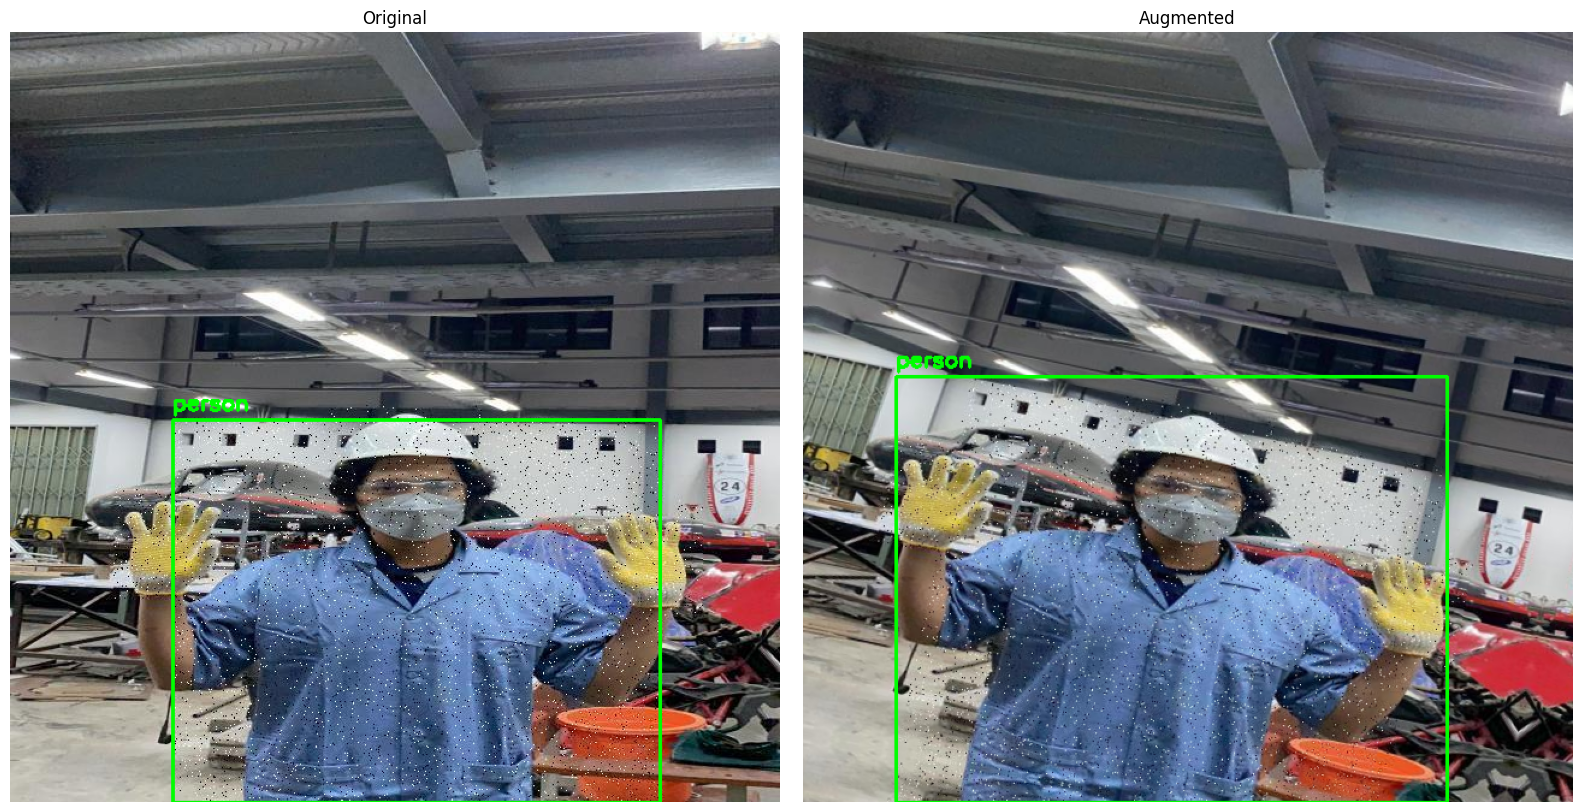

In [26]:
import matplotlib.pyplot as plt

CLASS_NAMES = [
    "person",
    "hardhat",
    "no hardhat",
    "safety vest",
    "no safety vest"
]

# اختيار أول صورة من train
train_images = DATA_ROOT / "train" / "images"
image_path = next(
    path for path in train_images.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

# تحديد ملف الـlabel المطابق للصورة
label_path = (
    DATA_ROOT / "train" / "labels" / f"{image_path.stem}.txt"
)

# قراءة الصورة وتحويل ألوانها من BGR إلى RGB
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# قراءة YOLO labels
bboxes = []
class_labels = []

for line in label_path.read_text().splitlines():
    parts = line.split()

    class_labels.append(int(parts[0]))
    bboxes.append([float(value) for value in parts[1:5]])

# تطبيق الـaugmentation على الصورة والصناديق
result = augmentation(
    image=image,
    bboxes=bboxes,
    class_labels=class_labels
)

augmented_image = result["image"]
augmented_bboxes = result["bboxes"]
augmented_classes = result["class_labels"]


# دالة ترسم YOLO bounding boxes على الصورة
def draw_yolo_boxes(image, boxes, labels):
    output = image.copy()
    height, width = output.shape[:2]

    for box, class_id in zip(boxes, labels):
        x_center, y_center, box_width, box_height = box

        x1 = int((x_center - box_width / 2) * width)
        y1 = int((y_center - box_height / 2) * height)
        x2 = int((x_center + box_width / 2) * width)
        y2 = int((y_center + box_height / 2) * height)

        class_id = int(class_id)
        class_name = CLASS_NAMES[class_id]

        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            output,
            class_name,
            (x1, max(y1 - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    return output


original_display = draw_yolo_boxes(
    image, bboxes, class_labels
)

augmented_display = draw_yolo_boxes(
    augmented_image, augmented_bboxes, augmented_classes
)

# عرض الصورتين جنبًا إلى جنب
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(original_display)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_display)
plt.title("Augmented")
plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
import shutil
from pathlib import Path

AUG_ROOT = Path("/content/WorkerSafety25_augmented_5cls")

# حماية من الكتابة فوق نسخة موجودة
if AUG_ROOT.exists():
    raise FileExistsError(
        "مجلد الداتا المعززة موجود مسبقًا. "
        "لا تعِد تشغيل هذه الخلية فوقه."
    )

# نسخ الداتا النظيفة كاملة إلى مجلد جديد
shutil.copytree(DATA_ROOT, AUG_ROOT)

print("Augmented dataset base created:")
print(AUG_ROOT)

Augmented dataset base created:
/content/WorkerSafety25_augmented_5cls


In [27]:
from tqdm.auto import tqdm

source_images = DATA_ROOT / "train" / "images"
source_labels = DATA_ROOT / "train" / "labels"

target_images = AUG_ROOT / "train" / "images"
target_labels = AUG_ROOT / "train" / "labels"

image_extensions = {".jpg", ".jpeg", ".png"}

image_paths = sorted([
    path for path in source_images.iterdir()
    if path.suffix.lower() in image_extensions
])

generated = 0
already_exists = 0
skipped_empty = 0
skipped_error = 0

for image_path in tqdm(image_paths, desc="Generating augmentations"):

    label_path = source_labels / f"{image_path.stem}.txt"

    augmented_image_name = (
        f"{image_path.stem}_aug{image_path.suffix.lower()}"
    )
    augmented_label_name = f"{image_path.stem}_aug.txt"

    output_image_path = target_images / augmented_image_name
    output_label_path = target_labels / augmented_label_name

    # منع تكرار الصور عند إعادة تشغيل الخلية
    if output_image_path.exists() and output_label_path.exists():
        already_exists += 1
        continue

    if not label_path.exists():
        skipped_error += 1
        continue

    # قراءة الصورة
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        skipped_error += 1
        continue

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    # قراءة YOLO labels
    bboxes = []
    class_labels = []

    for line in label_path.read_text().splitlines():
        parts = line.split()

        if len(parts) != 5:
            continue

        class_labels.append(int(parts[0]))
        bboxes.append([
            float(value) for value in parts[1:5]
        ])

    if len(bboxes) == 0:
        skipped_empty += 1
        continue

    # تطبيق augmentation
    try:
        result = augmentation(
            image=image_rgb,
            bboxes=bboxes,
            class_labels=class_labels
        )
    except Exception:
        skipped_error += 1
        continue

    augmented_image = result["image"]
    augmented_bboxes = result["bboxes"]
    augmented_classes = result["class_labels"]

    if len(augmented_bboxes) == 0:
        skipped_empty += 1
        continue

    # حفظ الصورة المعززة
    augmented_image_bgr = cv2.cvtColor(
        augmented_image,
        cv2.COLOR_RGB2BGR
    )

    saved = cv2.imwrite(
        str(output_image_path),
        augmented_image_bgr
    )

    if not saved:
        skipped_error += 1
        continue

    # إنشاء ملف YOLO label الجديد
    label_lines = []

    for class_id, bbox in zip(
        augmented_classes,
        augmented_bboxes
    ):
        # إبقاء الإحداثيات بين 0 و1
        bbox = [
            max(0.0, min(1.0, float(value)))
            for value in bbox
        ]

        label_line = (
            f"{int(class_id)} "
            + " ".join(
                f"{value:.6f}" for value in bbox
            )
        )

        label_lines.append(label_line)

    output_label_path.write_text(
        "\n".join(label_lines) + "\n"
    )

    generated += 1


print("\nAugmentation completed.")
print(f"Generated: {generated}")
print(f"Already existed: {already_exists}")
print(f"Skipped with no boxes: {skipped_empty}")
print(f"Skipped because of errors: {skipped_error}")

final_train_images = len(list(target_images.glob("*")))
final_train_labels = len(list(target_labels.glob("*.txt")))

print(f"\nFinal train images: {final_train_images}")
print(f"Final train labels: {final_train_labels}")

Generating augmentations:   0%|          | 0/3827 [00:00<?, ?it/s]


Augmentation completed.
Generated: 3827
Already existed: 0
Skipped with no boxes: 0
Skipped because of errors: 0

Final train images: 7654
Final train labels: 7654


In [28]:
from tqdm.auto import tqdm

source_images = DATA_ROOT / "train" / "images"
source_labels = DATA_ROOT / "train" / "labels"

target_images = AUG_ROOT / "train" / "images"
target_labels = AUG_ROOT / "train" / "labels"

image_extensions = {".jpg", ".jpeg", ".png"}

image_paths = sorted([
    path for path in source_images.iterdir()
    if path.suffix.lower() in image_extensions
])

generated = 0
already_exists = 0
skipped_empty = 0
skipped_error = 0

for image_path in tqdm(image_paths, desc="Generating augmentations"):

    label_path = source_labels / f"{image_path.stem}.txt"

    augmented_image_name = (
        f"{image_path.stem}_aug{image_path.suffix.lower()}"
    )
    augmented_label_name = f"{image_path.stem}_aug.txt"

    output_image_path = target_images / augmented_image_name
    output_label_path = target_labels / augmented_label_name

    # منع تكرار الصور عند إعادة تشغيل الخلية
    if output_image_path.exists() and output_label_path.exists():
        already_exists += 1
        continue

    if not label_path.exists():
        skipped_error += 1
        continue

    # قراءة الصورة
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        skipped_error += 1
        continue

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    # قراءة YOLO labels
    bboxes = []
    class_labels = []

    for line in label_path.read_text().splitlines():
        parts = line.split()

        if len(parts) != 5:
            continue

        class_labels.append(int(parts[0]))
        bboxes.append([
            float(value) for value in parts[1:5]
        ])

    if len(bboxes) == 0:
        skipped_empty += 1
        continue

    # تطبيق augmentation
    try:
        result = augmentation(
            image=image_rgb,
            bboxes=bboxes,
            class_labels=class_labels
        )
    except Exception:
        skipped_error += 1
        continue

    augmented_image = result["image"]
    augmented_bboxes = result["bboxes"]
    augmented_classes = result["class_labels"]

    if len(augmented_bboxes) == 0:
        skipped_empty += 1
        continue

    # حفظ الصورة المعززة
    augmented_image_bgr = cv2.cvtColor(
        augmented_image,
        cv2.COLOR_RGB2BGR
    )

    saved = cv2.imwrite(
        str(output_image_path),
        augmented_image_bgr
    )

    if not saved:
        skipped_error += 1
        continue

    # إنشاء ملف YOLO label الجديد
    label_lines = []

    for class_id, bbox in zip(
        augmented_classes,
        augmented_bboxes
    ):
        # إبقاء الإحداثيات بين 0 و1
        bbox = [
            max(0.0, min(1.0, float(value)))
            for value in bbox
        ]

        label_line = (
            f"{int(class_id)} "
            + " ".join(
                f"{value:.6f}" for value in bbox
            )
        )

        label_lines.append(label_line)

    output_label_path.write_text(
        "\n".join(label_lines) + "\n"
    )

    generated += 1


print("\nAugmentation completed.")
print(f"Generated: {generated}")
print(f"Already existed: {already_exists}")
print(f"Skipped with no boxes: {skipped_empty}")
print(f"Skipped because of errors: {skipped_error}")

final_train_images = len(list(target_images.glob("*")))
final_train_labels = len(list(target_labels.glob("*.txt")))

print(f"\nFinal train images: {final_train_images}")
print(f"Final train labels: {final_train_labels}")


Generating augmentations:   0%|          | 0/3827 [00:00<?, ?it/s]


Augmentation completed.
Generated: 0
Already existed: 3827
Skipped with no boxes: 0
Skipped because of errors: 0

Final train images: 7654
Final train labels: 7654


In [29]:
import yaml

yaml_path = AUG_ROOT / "data.yaml"

# قراءة ملف إعدادات YOLO
with open(yaml_path, "r") as file:
    data_config = yaml.safe_load(file)

# تغيير المسار إلى الداتا المعززة
data_config["path"] = str(AUG_ROOT)

# حفظ الملف بعد التعديل
with open(yaml_path, "w") as file:
    yaml.safe_dump(
        data_config,
        file,
        sort_keys=False,
        allow_unicode=True
    )

print("Updated data.yaml:\n")
print(yaml_path.read_text())

Updated data.yaml:

path: /content/WorkerSafety25_augmented_5cls
train: train/images
val: valid/images
test: test/images
names:
  0: person
  1: hardhat
  2: no hardhat
  3: safety vest
  4: no safety vest



In [30]:
valid_class_ids = {0, 1, 2, 3, 4}
image_extensions = {".jpg", ".jpeg", ".png"}

total_issues = 0

for split in ["train", "valid", "test"]:
    images_dir = AUG_ROOT / split / "images"
    labels_dir = AUG_ROOT / split / "labels"

    image_files = [
        path for path in images_dir.iterdir()
        if path.suffix.lower() in image_extensions
    ]
    label_files = list(labels_dir.glob("*.txt"))

    image_stems = {path.stem for path in image_files}
    label_stems = {path.stem for path in label_files}

    missing_labels = image_stems - label_stems
    orphan_labels = label_stems - image_stems

    invalid_lines = 0
    invalid_classes = 0
    invalid_coordinates = 0

    for label_path in label_files:
        for line in label_path.read_text().splitlines():
            parts = line.split()

            if len(parts) != 5:
                invalid_lines += 1
                continue

            try:
                class_id = int(parts[0])
                coordinates = [
                    float(value) for value in parts[1:5]
                ]
            except ValueError:
                invalid_lines += 1
                continue

            if class_id not in valid_class_ids:
                invalid_classes += 1

            if any(
                value < 0.0 or value > 1.0
                for value in coordinates
            ):
                invalid_coordinates += 1

    split_issues = (
        len(missing_labels)
        + len(orphan_labels)
        + invalid_lines
        + invalid_classes
        + invalid_coordinates
    )

    total_issues += split_issues

    print(f"\n{split.upper()}")
    print(f"Images: {len(image_files)}")
    print(f"Labels: {len(label_files)}")
    print(f"Images without labels: {len(missing_labels)}")
    print(f"Labels without images: {len(orphan_labels)}")
    print(f"Invalid lines: {invalid_lines}")
    print(f"Invalid class IDs: {invalid_classes}")
    print(f"Invalid coordinates: {invalid_coordinates}")

print("\nTotal issues:", total_issues)


TRAIN
Images: 7654
Labels: 7654
Images without labels: 0
Labels without images: 0
Invalid lines: 0
Invalid class IDs: 0
Invalid coordinates: 0

VALID
Images: 1093
Labels: 1093
Images without labels: 0
Labels without images: 0
Invalid lines: 0
Invalid class IDs: 0
Invalid coordinates: 0

TEST
Images: 548
Labels: 548
Images without labels: 0
Labels without images: 0
Invalid lines: 0
Invalid class IDs: 0
Invalid coordinates: 0

Total issues: 0


In [31]:
import shutil
from pathlib import Path

# ضغط مجلد الداتا المعززة داخل Colab
local_zip = shutil.make_archive(
    "/content/WorkerSafety25_augmented_5cls",
    "zip",
    "/content",
    "WorkerSafety25_augmented_5cls"
)

# مكان حفظ الملف في Google Drive
drive_zip = Path(
    "/content/drive/MyDrive/"
    "WorkerSafety25_augmented_5cls_train7654.zip"
)

# حماية من استبدال ملف موجود
if drive_zip.exists():
    raise FileExistsError(
        "ملف ZIP موجود مسبقًا في Google Drive."
    )

# نسخ الملف المضغوط إلى Drive
shutil.copy2(local_zip, drive_zip)

file_size_mb = drive_zip.stat().st_size / (1024 ** 2)

print("Saved successfully to Google Drive:")
print(drive_zip)
print(f"ZIP size: {file_size_mb:.1f} MB")

Saved successfully to Google Drive:
/content/drive/MyDrive/WorkerSafety25_augmented_5cls_train7654.zip
ZIP size: 838.1 MB
